In [ ]:
import os
import shutil
import tempfile
import time
import matplotlib.pyplot as plt
# from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
from monai.handlers.utils import from_engine
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, MeanIoU
from monai.networks.nets import UNet
from monai.transforms import (
    EnsureType,
    AsDiscrete,
    Activations,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Resized,
    SpatialPadd,
    BorderPadd,
    Orientationd,
    RandCropByPosNegLabeld,
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    Invertd,
    MapTransform,
    SpatialPadd,
    ResizeWithPadOrCropd

)
from monai.utils import set_determinism, first
from monai.networks.layers import Norm
from tqdm import tqdm
import glob
import torch
plt.rcParams["pdf.fonttype"] = 42
print_config()

In [2]:
data_dir = r"Processed NIFTI Dataset"
train_images = sorted(glob.glob(os.path.join(data_dir, "**", "post_1.img.gz"), recursive=True))
train_labels = sorted(glob.glob(os.path.join(data_dir, "**", "segmentation.img.gz"), recursive=True))
# files = [f for f in train_images if os.path.isfile(f)]
len(train_labels)

922

In [3]:
data_dicts = [{"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]
# data_dicts = [{"image": image_name} for image_name in train_images]
# train_files, test_files, val_files = data_dicts[0:91], data_dicts[91:110], data_dicts[110:130]
len(data_dicts)

922

In [4]:
import random
import math
random.seed(42)
random.shuffle(data_dicts)
# calculate splits
train_portion = math.ceil(len(data_dicts) * 0.7)
test_portion = math.floor(len(data_dicts) * 0.15)
valid_portion = math.floor(len(data_dicts) * 0.15)
print(train_portion)
print(test_portion)
print(valid_portion)
print((train_portion + test_portion + valid_portion) == len(data_dicts))
train_files, test_files, val_files = data_dicts[0:train_portion], data_dicts[train_portion:(train_portion+test_portion)], data_dicts[(train_portion+test_portion):(train_portion + test_portion + valid_portion)]

646
138
138
True


In [5]:
train_files 

[{'image': 'Processed NIFTI Dataset/Breast_MRI_029/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_029/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_648/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_648/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_918/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_918/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_684/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_684/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_825/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_825/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_712/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_712/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_305/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_305/segmentation.img.gz'},
 {'image': 'P

In [6]:
test_files

[{'image': 'Processed NIFTI Dataset/Breast_MRI_363/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_363/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_442/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_442/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_871/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_871/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_097/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_097/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_195/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_195/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_417/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_417/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_731/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_731/segmentation.img.gz'},
 {'image': 'P

In [7]:
len(train_files)

646

In [8]:
import numpy as np
load_trans = Compose([
        LoadImaged(keys=["image","label"]),
        EnsureChannelFirstd(keys=["image","label"])])

check_ds = Dataset(data=data_dicts,transform=load_trans)


In [9]:
data_dicts

[{'image': 'Processed NIFTI Dataset/Breast_MRI_029/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_029/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_648/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_648/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_918/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_918/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_684/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_684/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_825/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_825/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_712/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_712/segmentation.img.gz'},
 {'image': 'Processed NIFTI Dataset/Breast_MRI_305/post_1.img.gz',
  'label': 'Processed NIFTI Dataset/Breast_MRI_305/segmentation.img.gz'},
 {'image': 'P

In [5]:
import SimpleITK as sitk
import numpy as np
# store min/max values
all_mins = []
all_maxs = []
all_variance = []
all_dimension = []
all_height = []
all_width = []
all_spacing = []
all_direction = []
all_tumor_slices = []
all_tumour_volumns = []
# all_spacingX = []
# all_spacingY = []
# all_spacingZ =[]
# loop through dataset
for item in tqdm(data_dicts):
    img_meta = sitk.ReadImage(item["image"])
    label_meta = sitk.ReadImage(item["label"])
    img_np = sitk.GetArrayFromImage(img_meta)
    label_np = sitk.GetArrayFromImage(label_meta)
    # print(item)
    # img = item["image"]  # this is usually a numpy array
    all_mins.append(img_np.min())
    all_maxs.append(img_np.max())
    all_variance.append(np.var(img_np))
    all_spacing.append(img_meta.GetSpacing())
    H = img_meta.GetHeight()
    W = img_meta.GetWidth()
    D = img_meta.GetSize()[2]
    direction = img_meta.GetDirection()

    num_mask_slices = np.sum(np.any(label_np > 0, axis=(1, 2)))
    all_tumor_slices.append(num_mask_slices)
    # print(img[0].shape)
    # break
    all_height.append(H)
    all_width.append(W)
    all_dimension.append(D)
    all_direction.append(direction)

# overall min/max
dataset_min = np.min(all_mins)
dataset_max = np.max(all_maxs)


In [11]:
all_spacing

[(0.6836000084877014, 0.6836000084877014, 1.0999994277954102),
 (0.5859000086784363, 0.5859000086784363, 1.0),
 (0.6836000084877014, 0.6836000084877014, 1.100000023841858),
 (0.6640999913215637, 0.6640999913215637, 1.0),
 (0.6640999913215637, 0.6640999913215637, 1.0),
 (0.7031000256538391, 0.7031000256538391, 1.0000028610229492),
 (0.7813000082969666, 0.7813000082969666, 1.2000017166137695),
 (0.7031000256538391, 0.7031000256538391, 1.0999994277954102),
 (0.7813000082969666, 0.7813000082969666, 1.1000006198883057),
 (0.6836000084877014, 0.6836000084877014, 1.0),
 (0.7031000256538391, 0.7031000256538391, 1.0000004768371582),
 (0.7031000256538391, 0.7031000256538391, 1.000001311302185),
 (0.8482142686843872, 0.8482142686843872, 1.100000023841858),
 (0.7031000256538391, 0.7031000256538391, 1.0),
 (0.6836000084877014, 0.6836000084877014, 1.0999974012374878),
 (0.6640999913215637, 0.6640999913215637, 1.0000004768371582),
 (0.8928571343421936, 0.8928571343421936, 1.1999999284744263),
 (0.722

In [6]:
import seaborn as sns
import pandas as pd

all_mins_float = [float(x) for x in all_mins]
all_maxs_float = [float(x) for x in all_maxs]
all_variances_float = [float(x) for x in all_variance]
all_height_float = [float(x) for x in all_height]
all_width_float = [float(x) for x in all_width]
all_dimension_float = [float(x) for x in all_dimension]
spacing_array = np.array(all_spacing) 
x_spacing = spacing_array[:, 0]
y_spacing = spacing_array[:, 1]
z_spacing = spacing_array[:, 2]
all_tumor_slices_float = [float(x) for x in all_tumor_slices]

df = pd.DataFrame({
    "Min Intensity": all_mins_float,
    "Max Intensity": all_maxs_float,
    "Variances": all_variances_float,
    "Image height": all_height_float,
    "Image width" : all_width_float,
    "Image dimension" : all_dimension_float,
    "num Slices Tumour": all_tumor_slices_float,
    "x spacing" : x_spacing,
    "y spacing" : y_spacing,
    "z spacing" : z_spacing
})



In [ ]:
all_dimension

[192,
 160,
 192,
 158,
 200,
 174,
 176,
 176,
 176,
 176,
 196,
 160,
 160,
 168,
 192,
 200,
 176,
 192,
 182,
 142,
 144,
 152,
 142,
 174,
 188,
 144,
 160,
 142,
 164,
 144,
 144,
 176,
 174,
 144,
 112,
 176,
 192,
 142,
 188,
 160,
 200,
 176,
 224,
 160,
 160,
 160,
 198,
 176,
 178,
 176,
 144,
 192,
 176,
 172,
 170,
 182,
 160,
 164,
 168,
 204,
 176,
 176,
 192,
 168,
 174,
 176,
 170,
 128,
 188,
 192,
 150,
 168,
 162,
 208,
 156,
 192,
 160,
 160,
 160,
 200,
 198,
 160,
 148,
 160,
 176,
 146,
 144,
 162,
 192,
 160,
 166,
 180,
 208,
 176,
 150,
 128,
 166,
 192,
 160,
 208,
 178,
 176,
 156,
 208,
 168,
 156,
 152,
 196,
 176,
 192,
 198,
 174,
 190,
 196,
 160,
 160,
 176,
 176,
 170,
 144,
 188,
 182,
 120,
 146,
 158,
 200,
 162,
 192,
 188,
 160,
 192,
 166,
 192,
 144,
 168,
 146,
 176,
 144,
 142,
 192,
 192,
 178,
 124,
 200,
 176,
 188,
 192,
 176,
 144,
 144,
 174,
 160,
 142,
 142,
 96,
 180,
 176,
 146,
 176,
 190,
 174,
 176,
 164,
 96,
 176,
 154,
 142,


Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.


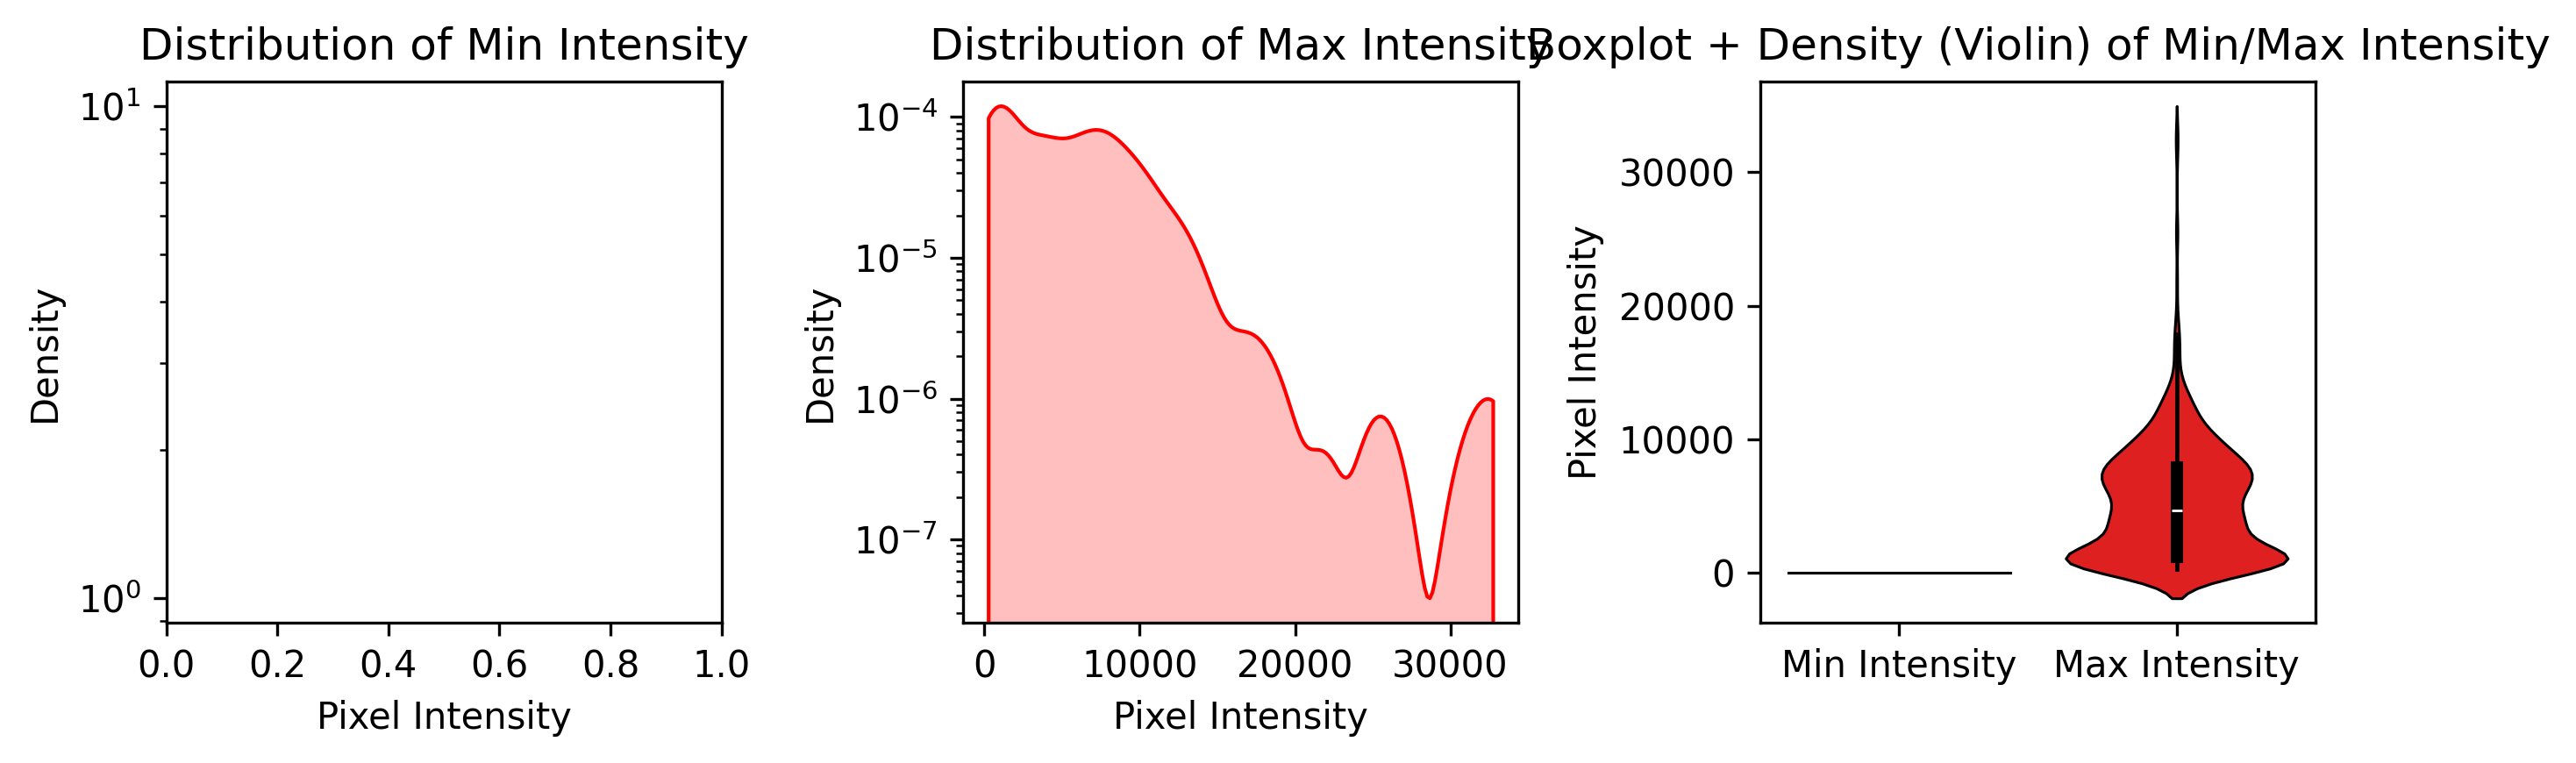

Dataset min: 0, max: 32767 min_of_max: 266 mean_of_max: 5211.131236442517 median_of_max: 4656.0


In [ ]:
print(f"Dataset min: {dataset_min}, max: {dataset_max} min_of_max: {np.min(all_maxs)} mean_of_max: {np.mean(all_maxs)} median_of_max: {np.median(all_maxs)}")
plt.figure(figsize=(9,3), dpi = 300)

plt.subplot(131)
sns.kdeplot(df["Min Intensity"], fill=True, color="blue")
plt.title("Distribution of Min Intensity")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.yscale("log")

plt.subplot(132)
sns.kdeplot(df["Max Intensity"], fill=True, cut=0, clip=(df["Max Intensity"].min(),df["Max Intensity"].max()) ,color="red")
plt.title("Distribution of Max Intensity")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.yscale("log")

plt.subplot(133)
sns.violinplot(data=df[["Min Intensity", "Max Intensity"]], inner="box", palette=["blue", "red"], linecolor="black", linewidth=0.75)
plt.title("Boxplot + Density (Violin) of Min/Max Intensity")
plt.ylabel("Pixel Intensity")

# Adjust layout
plt.tight_layout()
plt.show()


mean spacing X: 0.7204204546267453 mean spacing Y: 0.7204204546267453 mean spacing Z: 1.0689911466099953
max spacing X: 1.25 min spacing X: 0.5077999830245972
max spacing Y: 1.25 min spacing Y: 0.5077999830245972
max spacing Z: 2.5 min spacing Z: 0.9999964833259583


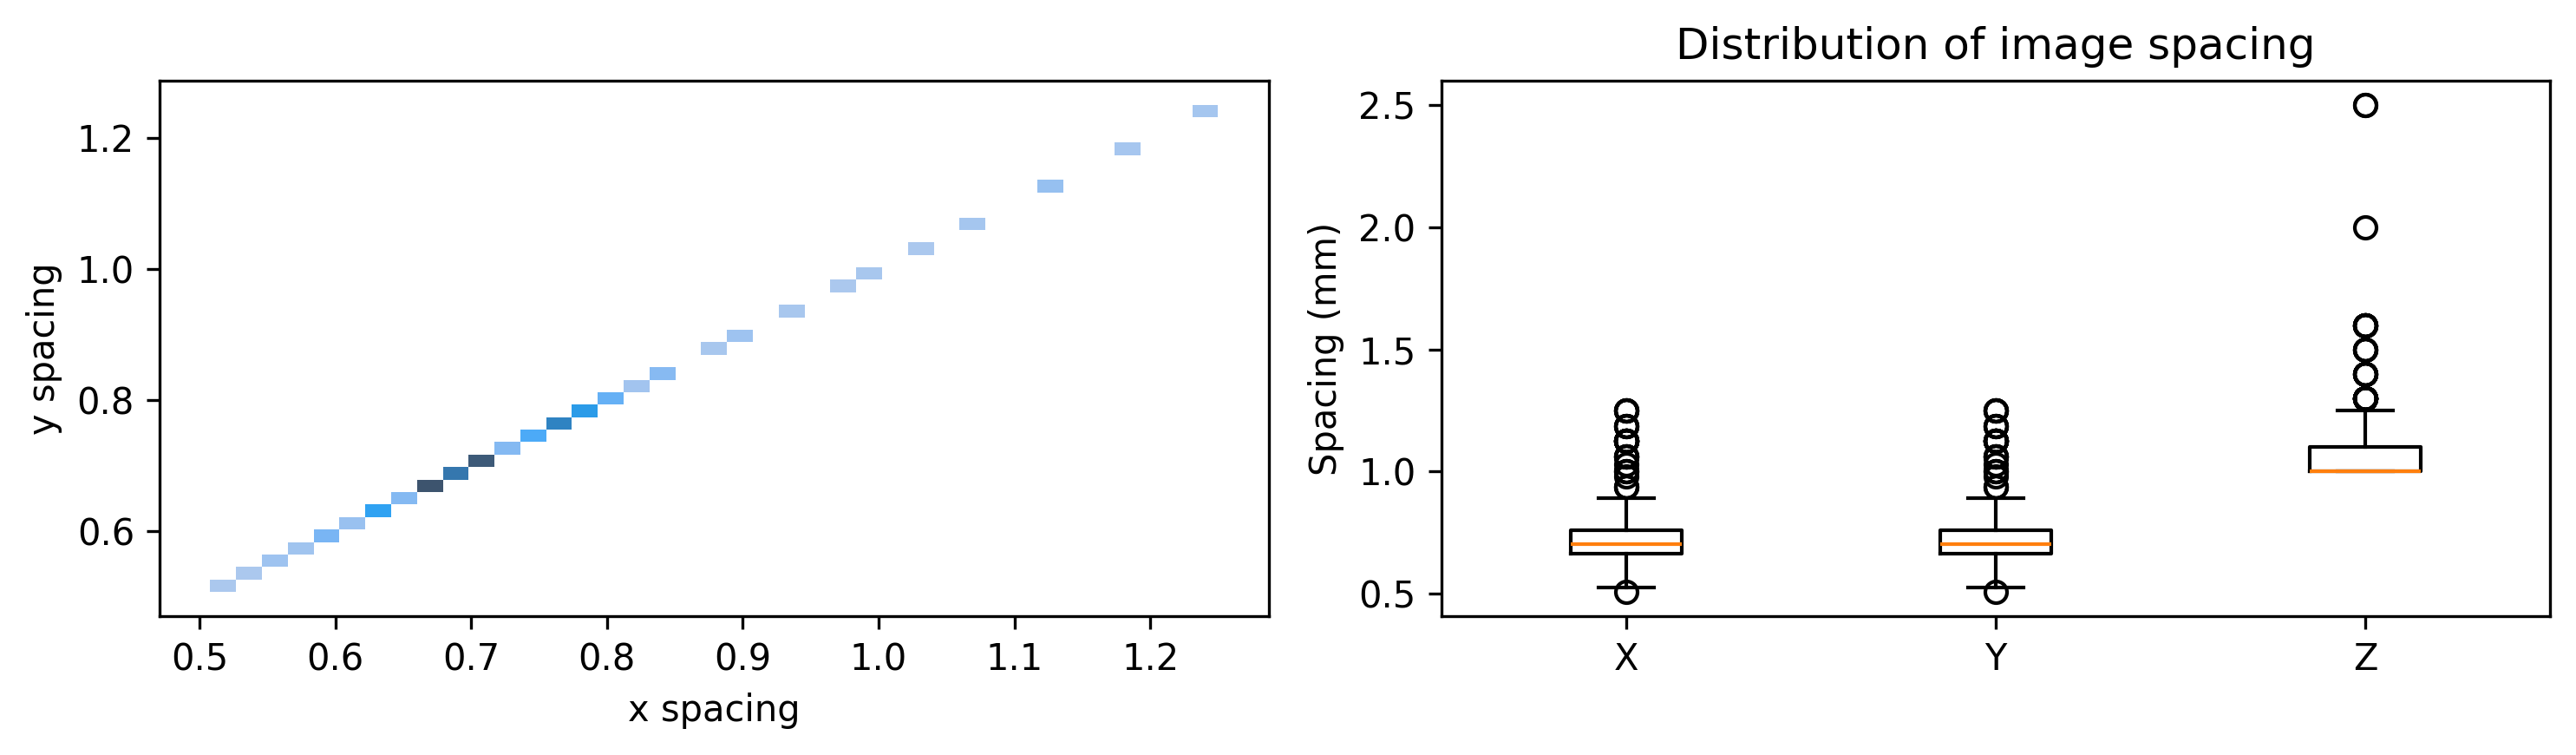

In [23]:
print(f"mean spacing X: {np.mean(x_spacing)} mean spacing Y: {np.mean(y_spacing)} mean spacing Z: {np.mean(z_spacing)}")
print(f"max spacing X: {np.max(x_spacing)} min spacing X: {np.min(x_spacing)}")
print(f"max spacing Y: {np.max(y_spacing)} min spacing Y: {np.min(y_spacing)}")
print(f"max spacing Z: {np.max(z_spacing)} min spacing Z: {np.min(z_spacing)}")
plt.figure(figsize=(10, 3),dpi=300)

# plt.subplot(1, 5, 1)
# plt.hist(x_spacing, bins=20, color='skyblue')
# plt.title('X spacing (mm)')

# plt.subplot(1, 5, 2)
# plt.hist(y_spacing, bins=20, color='lightgreen')
# plt.title('Y spacing (mm)')

# plt.subplot(1, 5, 3)
# plt.hist(z_spacing, bins=20, color='salmon')
# plt.title('Z spacing (slice thickness, mm)')
# df_melted = pd.melt(df, var_name="spacing_type", value_name="value")
plt.subplot(1, 2, 1)
sns.histplot(df, x="x spacing", y="y spacing")
# plt.title('Distribution of image spacing')


plt.subplot(1, 2, 2)
plt.boxplot(df[["x spacing", "y spacing", "z spacing"]], tick_labels=['X', 'Y', 'Z'])
plt.ylabel('Spacing (mm)')
plt.title('Distribution of image spacing')




plt.tight_layout()
plt.show()

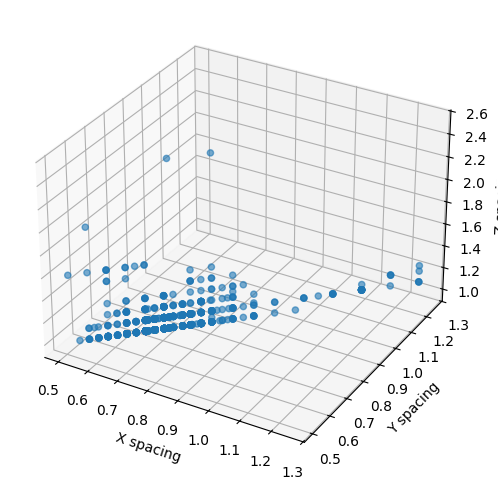

In [38]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['x spacing'], df['y spacing'], df['z spacing'], alpha=0.6)
# ax.plot_surface(df['x spacing'], df['y spacing'], df['z spacing'], cmap='viridis', edgecolor='green')
ax.set_xlabel('X spacing')
ax.set_ylabel('Y spacing')
ax.set_zlabel('Z spacing')
plt.show()

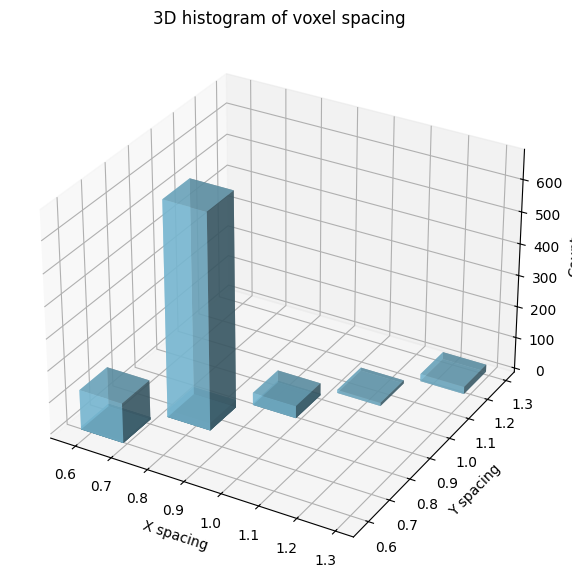

In [39]:
from mpl_toolkits.mplot3d import Axes3D
# Get spacing arrays
x = df['x spacing'].values
y = df['y spacing'].values
z = df['z spacing'].values

# Define number of bins per axis
bins = [5, 5, 5]  # you can adjust

# Compute 3D histogram
hist, edges = np.histogramdd(np.vstack([x, y, z]).T, bins=bins)

# Get bin centers
x_centers = (edges[0][:-1] + edges[0][1:]) / 2
y_centers = (edges[1][:-1] + edges[1][1:]) / 2
z_centers = (edges[2][:-1] + edges[2][1:]) / 2
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Iterate over each bin
for i, xi in enumerate(x_centers):
    for j, yj in enumerate(y_centers):
        for k, zk in enumerate(z_centers):
            count = hist[i,j,k]
            if count > 0:
                # draw bar at (xi, yj, zk) with height=count
                ax.bar3d(xi, yj, zk, 
                         dx=(edges[0][1]-edges[0][0])*0.8, 
                         dy=(edges[1][1]-edges[1][0])*0.8, 
                         dz=count, 
                         color='skyblue', alpha=0.7)

ax.set_xlabel('X spacing')
ax.set_ylabel('Y spacing')
ax.set_zlabel('Count')
plt.title('3D histogram of voxel spacing')
plt.show()

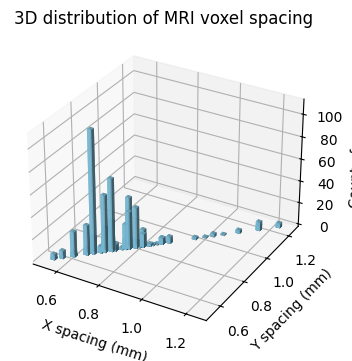

In [44]:
from mpl_toolkits.mplot3d import Axes3D

# --- Example data (replace this with your df) ---
# df = your DataFrame containing ['x_spacing','y_spacing','z_spacing']
x = df['x spacing'].values
y = df['y spacing'].values
z = df['z spacing'].values

# --- 1. Bin the spacing values (for grouping) ---
# Choose bin edges or use np.unique if discrete spacings
xbins = np.unique(np.round(x, 4))
ybins = np.unique(np.round(y, 4))
zbins = np.unique(np.round(z, 4))

# 3D histogram
hist, edges = np.histogramdd(np.vstack([x, y, z]).T, 
                             bins=[xbins, ybins, zbins])

# --- 2. Prepare bar positions ---
xpos, ypos, zpos = np.meshgrid(
    (edges[0][:-1] + edges[0][1:]) / 2,
    (edges[1][:-1] + edges[1][1:]) / 2,
    (edges[2][:-1] + edges[2][1:]) / 2,
    indexing="ij"
)

xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)  # start bars from zero

# bar height = counts
dz = hist.flatten()

# filter out zeros to keep only non-empty bins
mask = dz > 0
xpos, ypos, zpos, dz = xpos[mask], ypos[mask], zpos[mask], dz[mask]

dx = dy = 0.02  # bar base size (adjust if your spacing units differ)

# --- 3. Plot ---
fig = plt.figure(figsize=(4,4), dpi=100)
ax = fig.add_subplot(111, projection='3d')

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True, color='skyblue', alpha=0.8)

ax.set_xlabel('X spacing (mm)')
ax.set_ylabel('Y spacing (mm)')
ax.set_zlabel('Count of scans')
plt.title('3D distribution of MRI voxel spacing')
plt.show()

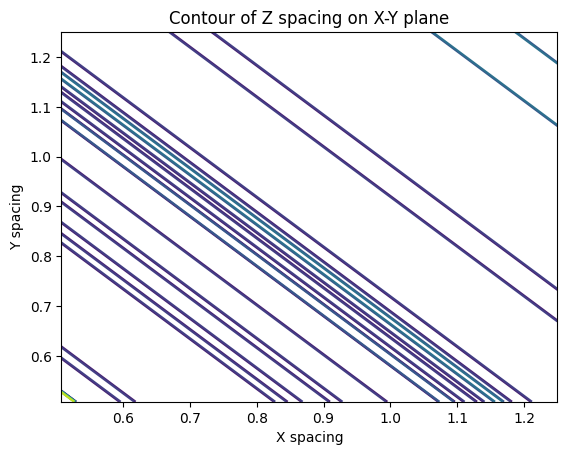

In [34]:
from scipy.interpolate import griddata

x = df['x spacing'].values
y = df['y spacing'].values
z = df['z spacing'].values

# Create grid
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
X, Y = np.meshgrid(xi, yi)

# Interpolate Z values onto grid
Z = griddata((x, y), z, (X, Y), method='nearest')

plt.contour(X, Y, Z, levels=10)
plt.xlabel('X spacing')
plt.ylabel('Y spacing')
plt.title('Contour of Z spacing on X-Y plane')
plt.show()

In [36]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde

x = df['x spacing'].values
y = df['y spacing'].values
z = df['z spacing'].values

# Compute 3D density
xyz = np.vstack([x, y, z])
density = gaussian_kde(xyz)(xyz)
idx = density.argsort()
x, y, z, density = x[idx], y[idx], z[idx], density[idx]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x, y, z, c=density, cmap='viridis', s=50)
ax.set_xlabel('X spacing')
ax.set_ylabel('Y spacing')
ax.set_zlabel('Z spacing')
plt.colorbar(sc, ax=ax, label='Density')
plt.title('3D density of voxel spacing')
plt.show()

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

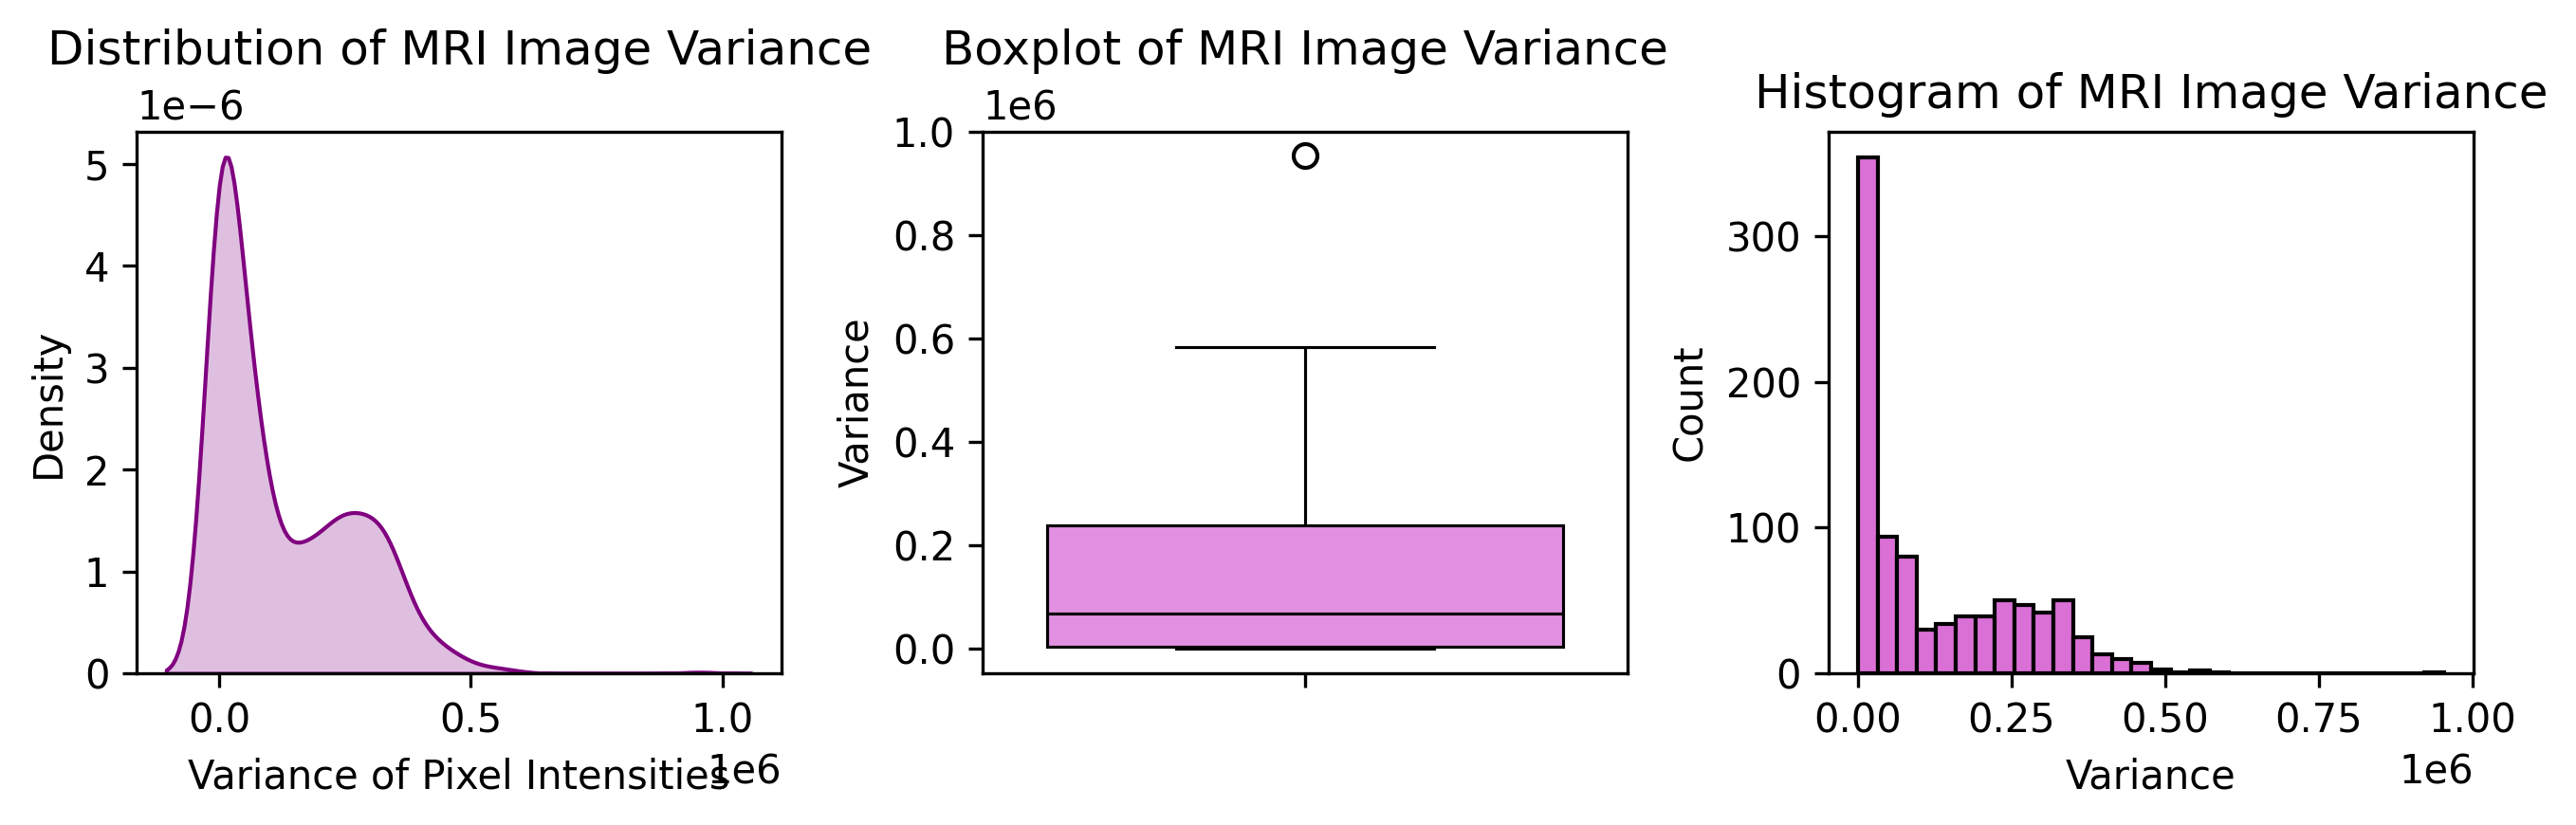

In [13]:
plt.figure(figsize=(9,3), dpi=300)
plt.subplot(131)
sns.kdeplot(df["Variances"], fill=True, color="purple")
plt.title("Distribution of MRI Image Variance")
plt.xlabel("Variance of Pixel Intensities")
plt.ylabel("Density")

plt.subplot(132)
sns.boxplot(y=df["Variances"], color="violet",linecolor="black",linewidth=0.75)
plt.title("Boxplot of MRI Image Variance")
plt.ylabel("Variance")

plt.subplot(133)
plt.hist(df["Variances"], bins=30, color="orchid", edgecolor="black")
plt.title("Histogram of MRI Image Variance")
plt.xlabel("Variance")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

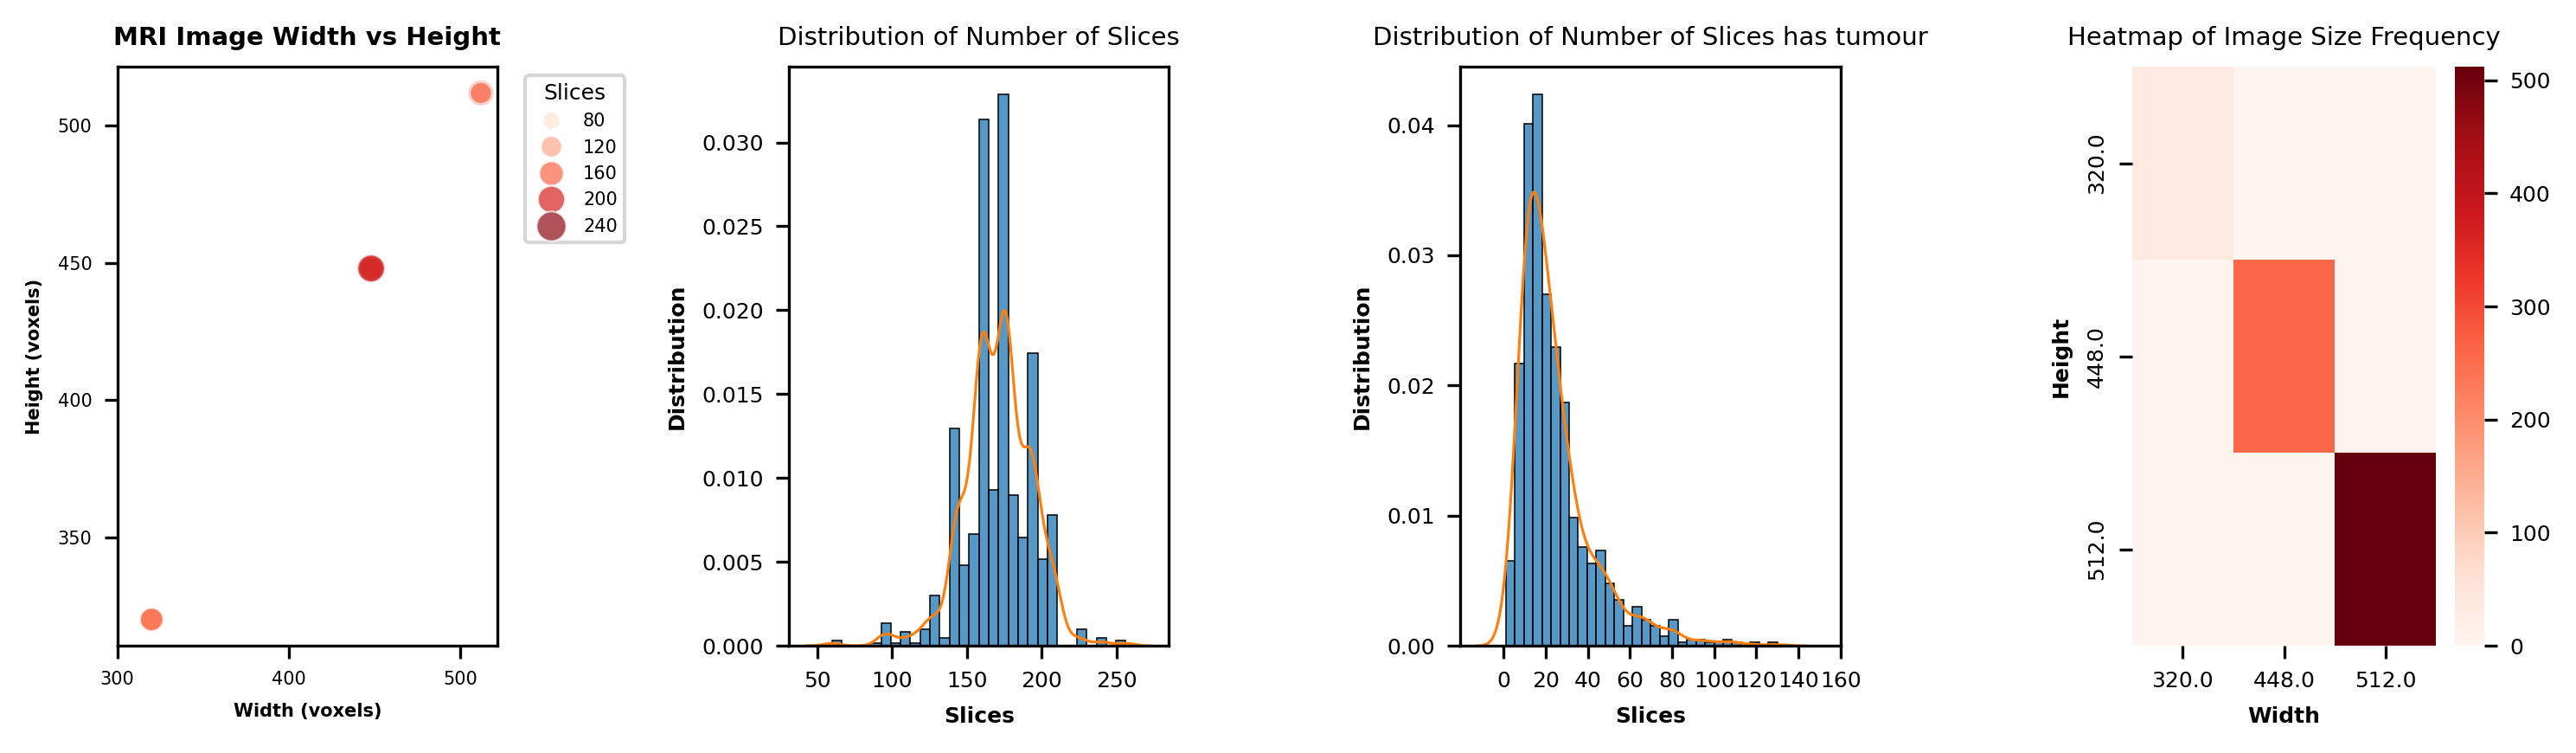

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3), dpi=300)
plt.subplot(141)
sns.scatterplot(data=df, x="Image width", y="Image height", size="Image dimension", hue="Image dimension", palette="Reds", alpha=0.7)
plt.title("MRI Image Width vs Height", fontsize=7, fontweight='bold')
plt.xlabel("Width (voxels)", fontsize=5, fontweight='bold')
plt.ylabel("Height (voxels)", fontsize=5, fontweight='bold')
plt.xticks([300,400,500],fontsize=5, rotation=0, color='black')
plt.yticks(fontsize=5, color='black')
plt.legend(title="Slices", bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=5, title_fontsize=6)

plt.subplot(142)
ax = sns.histplot(df["Image dimension"], bins=30, color="tab:blue", edgecolor="black", stat="density")

# KDE line
sns.kdeplot(df["Image dimension"], color="tab:orange", linewidth=0.75,ax=ax)
plt.title("Distribution of Number of Slices", fontsize=7)
plt.yticks(fontsize=6, color='black')
plt.xticks([50,100,150,200,250],fontsize=6, color='black')
plt.xlabel("Slices",fontsize=6,fontweight="bold")
plt.ylabel("Distribution",fontsize=6,fontweight="bold")

plt.subplot(143)
ax = sns.histplot(df["num Slices Tumour"], bins=30, color="tab:blue", edgecolor="black", stat="density")

# KDE line
sns.kdeplot(df["num Slices Tumour"], color="tab:orange", linewidth=0.75,ax=ax)
plt.title("Distribution of Number of Slices has tumour", fontsize=7)
plt.yticks(fontsize=6, color='black')
plt.xticks([0, 20,40,60,80,100,120,140,160],fontsize=6, color='black')
plt.xlabel("Slices",fontsize=6,fontweight="bold")
plt.ylabel("Distribution",fontsize=6,fontweight="bold")
size_counts = df.groupby(["Image width", "Image height"]).size().reset_index(name='Count')
size_pivot = size_counts.pivot(index="Image height", columns="Image width", values="Count").fillna(0)
# print(size_counts)
# print(size_pivot)
# plt.figure(figsize=(10,8))
plt.subplot(144)
ax = sns.heatmap(size_pivot, cmap="Reds",vmin=0, vmax=512)
plt.title("Heatmap of Image Size Frequency",fontsize=7)
plt.xlabel("Width",fontsize=6,fontweight="bold")
plt.ylabel("Height",fontsize=6,fontweight="bold")
plt.yticks(fontsize=6, color='black')
plt.xticks(fontsize=6, color='black')
cbar = ax.collections[0].colorbar  # get colorbar
cbar.ax.tick_params(labelsize=6)  # set tick font size
# plt.legend(title="number of pixels", bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=5, title_fontsize=6)
# ax.set_xticks([] + 0.5)  # offset by 0.5 for heatmap
# ax.set_yticks([] + 0.5)

plt.tight_layout()
plt.show()

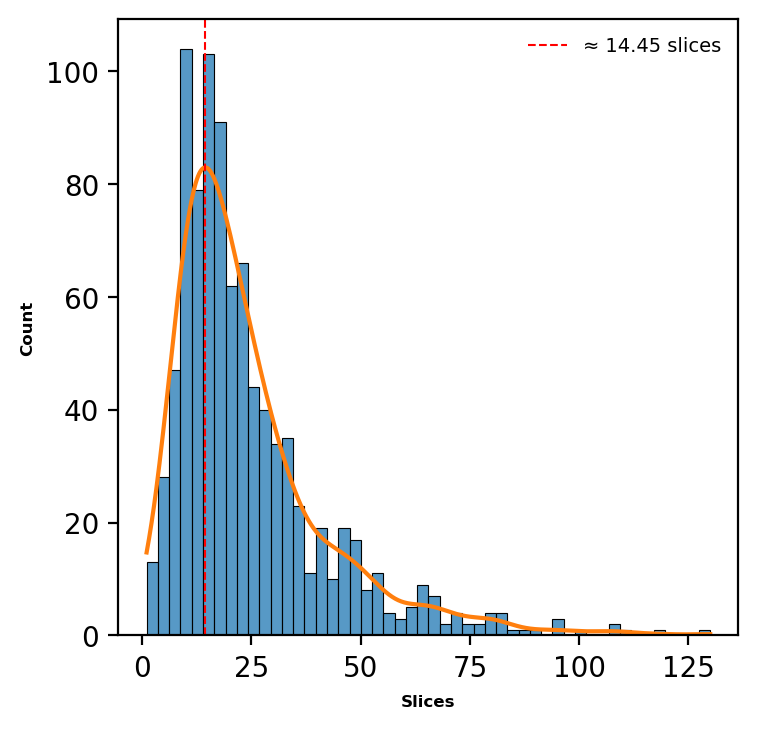

In [9]:
from scipy.stats import gaussian_kde
def compute_tumor_volume(mask, spacing):
    """
    mask: 3D tensor or numpy array (binary tumor mask)
    spacing: tuple/list of (dx, dy, dz) in mm
    """
    voxel_volume = np.prod(spacing)  # mm³ per voxel
    tumor_voxels = np.sum(mask > 0)
    tumor_volume = tumor_voxels * voxel_volume  # mm³
    return tumor_volume

bins = 50
data = df["num Slices Tumour"]
bin_width = (data.max() - data.min()) / bins

plt.figure(figsize=(4,4),dpi=200)

ax = sns.histplot(data, bins=bins, color="tab:blue", edgecolor="black", stat="count")
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), len(data))
y = kde(x) * len(data) * bin_width
ax.plot(x, y, color="tab:orange", linewidth=1.5)
mode = x[np.argmax(y)]
ax.axvline(mode, color="red", linestyle="--", label=f"≈ {mode:.2f} slices", linewidth= 0.75)
ax.legend(fontsize=7,loc='upper right', frameon=False )
# KDE line
# sns.kdeplot(df["num Slices Tumour"], color="tab:orange", linewidth=0.75,ax=ax)
# plt.title("Distribution of Number of Slices has tumour", fontsize=7)
# plt.yticks(fontsize=6, color='black')
# plt.xticks([0, 20,40,60,80,100,120,140,160],fontsize=6, color='black')
plt.xlabel("Slices",fontsize=6,fontweight="bold")
plt.ylabel("Count",fontsize=6,fontweight="bold")
plt.show()

In [ ]:
# class DebugShaped(MapTransform):
#     def __call__(self, data):
#         for key in self.keys:
#             print(f"{key} shape: {data[key].shape}")
#         return data

train_transforms = Compose(
    [
        LoadImaged(keys=["image","label"]),
        EnsureChannelFirstd(keys=["image","label"]),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=0,
            a_max=20000,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image","label"], source_key="image"),
        Orientationd(keys=["image","label"], axcodes="RAS"),
        # Resized(keys=["image","label"], spatial_size=(512, 512, 192), size_mode="all",mode=["bilinear","nearest"]),
        # # ResizeWithPadOrCropd(keys=["image","label"], spatial_size=(128, 128, 192)),
        # SpatialPadd(keys=["image","label"], spatial_size=(256, 256, 192),mode="minimum",method="symmetric"),
        Spacingd(keys=["image","label"], pixdim=(0.72, 0.72, 1.07), mode=("bilinear", "nearest")),
        Resized(keys=["image","label"], spatial_size=(256, 256, 192), size_mode="all",mode=["bilinear","nearest"]),
        
        # SpatialPadd(keys=["image","label"], spatial_size=(256, 256, 192),mode="minimum",method="symmetric"),
        # BorderPadd(),
        
        # SpatialPadd(keys=["image","label"], spatial_size=(256, 256, 192),mode="constant",method="symmetric"),
        ResizeWithPadOrCropd(keys=["image","label"], spatial_size=(256, 256, 192)),
        
        RandCropByPosNegLabeld(
            keys=["image","label"],
            label_key="label",
            spatial_size=(128, 128, 16),
            pos=2,
            neg=2,
            num_samples=4,
            image_key="image",
            image_threshold=0,
        ),
        
        # user can also add other random transforms
        # RandAffined(
        #     keys=['image', 'label'],
        #     mode=('bilinear', 'nearest'),
        #     prob=1.0, spatial_size=(96, 96, 96),
        #     rotate_range=(0, 0, np.pi/15),
        #     scale_range=(0.1, 0.1, 0.1)),
    ]
)
val_transforms = Compose(
    [
        LoadImaged(keys=["image","label"]),
        EnsureChannelFirstd(keys=["image","label"]),
        CropForegroundd(keys=["image","label"], source_key="image", allow_smaller=True),
        Orientationd(keys=["image","label"], axcodes="RAS"),
        Spacingd(keys=["image","label"], pixdim=(0.72, 0.72, 1.07), mode=("bilinear", "nearest")),
        # Resized(keys=["image","label"], spatial_size=(128, 128, 192), size_mode="all",mode=["bilinear","nearest"]),
        CropForegroundd(keys=["image","label"], source_key="image", allow_smaller=True),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=0,
            a_max=20000,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        
        # ResizeWithPadOrCropd(keys=["image","label"], spatial_size=(256, 256, 192))
    ]
)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [6]:
from itertools import islice
check_ds = Dataset(data=train_files, transform=train_transforms)
check_loader = DataLoader(check_ds, batch_size=1)
check_data = first(check_loader)

In [107]:
i=0
check_data = None
for item in check_loader:
    check_data = item
    i +=1
    if i==2:
        break

torch.Size([128, 128, 16])
16


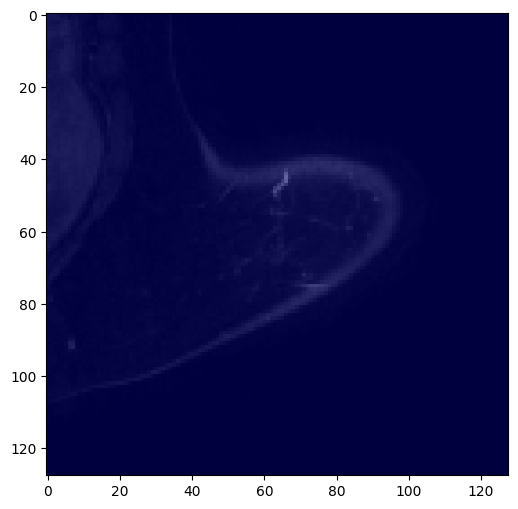

In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.pyplot as plt
image , label = check_data["image"][0][0], check_data["label"][0][0]
H, W, D = image.shape
print(image.shape)
print(D)
# nii_norm = (nii_np - nii_np.min()) / (nii_np.max() - nii_np.min()) * 255
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(image[:, :, 0], cmap='gray', vmin=0, vmax=image.max())
lbl = ax.imshow(label[:, :, 0], cmap='jet', alpha=0.5, vmin=0, vmax=label.max())

def update(frame):
    im.set_data(image[:, :, frame])
    lbl.set_data(label[:, :, frame])
    return [im, lbl]


ani = FuncAnimation(fig, update, frames=D, interval=100)
ani.save("mri_animation3.gif", writer=PillowWriter(fps=20))
plt.show()

image shape: torch.Size([96, 96, 16])


IndexError: index 135 is out of bounds for dimension 2 with size 16

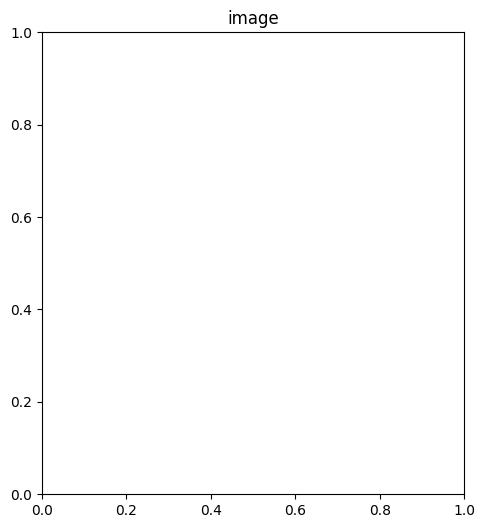

In [9]:
# check_data = first(check_loader)
image ,label = check_data["image"][0][0], check_data["label"][0][0]
print(f"image shape: {image.shape}")
# plot the slice [:, :, 80]
plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(image[:, :,135], cmap="grey",vmin=0, vmax=image.max())
plt.imshow(label[:, :,135],cmap="jet",alpha=0.5)
plt.show()
label[:, :,135].max()

In [8]:
train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0, num_workers=32)
# train_ds = Dataset(data=train_files, transform=train_transforms)

# use batch_size=2 to load images and use RandCropByPosNegLabeld
# to generate 8 x 4 images for network training
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=32)

test_ds = CacheDataset(data=test_files, transform=val_transforms, cache_rate=1.0, num_workers=32)
# val_ds = Dataset(data=val_files, transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=1, num_workers=32)

val_ds = CacheDataset(data=val_files, transform=val_transforms, cache_rate=1.0, num_workers=32)
# val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=32)

Loading dataset: 100%|██████████| 138/138 [03:42<00:00,  1.61s/it]


In [9]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/segmentation_experiment2")


In [10]:

def log_batch_image_label_pred(writer, images, labels, preds, tag="Train", epoch=0, fps=5):
    """
    Log a batch of image, label, and prediction to TensorBoard as a video.

    Args:
        writer: SummaryWriter object.
        images: torch.Tensor, shape [B, C, H, W, D] or [B, H, W, D]
        labels: torch.Tensor, same shape as images
        preds: torch.Tensor, same shape as images
        tag: str, prefix for TensorBoard
        step: int, global step (epoch)
        fps: int, frames per second
    """
    B = images.shape[0]
    # print(B)
    for i in range(B):
        img = images[i,0] * 100
        
        lbl = labels[i,0]
        pred = preds[i,0]
        # print(img.shape)
        # normalize image to [0,1]
        # img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        lbl = (lbl > 0).float()  # binary mask
        pred = (pred > 0.5).float()  # threshold prediction

        img = img.permute(2,0,1).unsqueeze(0).unsqueeze(2) 
        lbl = lbl.permute(2,0,1).unsqueeze(0).unsqueeze(2) 
        pred = pred.permute(2,0,1).unsqueeze(0).unsqueeze(2) 

        img = img.repeat(1, 1, 3, 1, 1) 
        lbl = lbl.repeat(1, 1, 3, 1, 1) 
        pred = pred.repeat(1, 1, 3, 1, 1) 
        
        writer.add_video(f"{tag}_image/Image_{i}", img, global_step=epoch, fps=fps)
        writer.add_video(f"{tag}_label/Label_{i}", lbl, global_step=epoch, fps=fps)
        writer.add_video(f"{tag}_pred/Prediction_{i}", pred, global_step=epoch, fps=fps)
def log_batch_image_label_pred_eval(writer, images, labels, preds, tag="Train", epoch=0, fps=5):
    """
    Log a batch of image, label, and prediction to TensorBoard as a video.

    Args:
        writer: SummaryWriter object.
        images: torch.Tensor, shape [B, C, H, W, D] or [B, H, W, D]
        labels: torch.Tensor, same shape as images
        preds: torch.Tensor, same shape as images
        tag: str, prefix for TensorBoard
        step: int, global step (epoch)
        fps: int, frames per second
    """
    # print(f"image len: {len(images)}")
    # print(images.shape)
    # print(len(labels))
    # print(labels.shape)
    B, C, H, W, D = images.shape[0], images.shape[1], images.shape[2], images.shape[3], images.shape[4]

    # print(B)
    for i in range(B):
        # print(images[i].shape)
        img = images[i][0] * 10
        img = img.permute(2,0,1).unsqueeze(0).unsqueeze(2) 
        img = img.repeat(1, 1, 3, 1, 1)
        writer.add_video(f"{tag}_image/Image_{i}", img, global_step=epoch, fps=fps)

    B_val = labels[0].shape[0]
    # print(B_val)
    for i in range(B_val):

        lbl = labels[0][i]
        pred = preds[0][i]
        # print(lbl.shape)
        # print(img.shape)
        # normalize image to [0,1]
        # img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        lbl = (lbl > 0).float()  # binary mask
        pred = (pred > 0.5).float()  # threshold prediction

        
        lbl = lbl.permute(2,0,1).unsqueeze(0).unsqueeze(2) 
        pred = pred.permute(2,0,1).unsqueeze(0).unsqueeze(2) 

         
        lbl = lbl.repeat(1, 1, 3, 1, 1) 
        pred = pred.repeat(1, 1, 3, 1, 1) 
        
        
        writer.add_video(f"{tag}_label/Label_{i}", lbl, global_step=epoch, fps=fps)
        writer.add_video(f"{tag}_pred/Prediction_{i}", pred, global_step=epoch, fps=fps)
        # writer.add_video(f"{tag}_Sample{i}", frames, global_step=step, fps=fps)

In [ ]:
# standard PyTorch program style: create UNet, DiceLoss and Adam optimizer
device = torch.device("cuda:0")
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128, 256), # (32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")
IoU_metric = MeanIoU(include_background=False, reduction="mean")
class_IoU = MeanIoU(include_background=True, reduction="none")

In [14]:
max_epochs = 1000000
val_interval = 10
best_dice = -1
best_IoU = -1
best_metric_epoch = -1
epoch_loss_values = []
dice_values = []
IoU_values = []
post_pred = Compose([AsDiscrete(argmax=True,to_onehot=2)])
post_label = Compose([ AsDiscrete(to_onehot=2)])

for epoch in range(max_epochs):
    # print("training"+"-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 1
    pbar = tqdm(train_loader)
    for batch_data in pbar:
        step += 1
        # print(f"input shape: {batch_data['image'].shape}")
        # print(f"label shape: {batch_data['label'].shape}")
        # print(f"label max: {batch_data['label'].max()}")
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        
    #     break
    # break
        optimizer.zero_grad()
        outputs = model(inputs)
        # log_batch_image_label_pred(writer, inputs, labels, outputs, tag=f"Train_{epoch}_{step}", epoch=epoch)
        # print(f"out shape: {outputs.shape}")
        # print(f"label shape: {labels.shape}")
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_description(f"loss: {loss.item():.4f}")
        # print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")
    writer.add_scalar("train/loss", epoch_loss, epoch)
    
    
    model.eval()
    
    with torch.no_grad():
        val_inputs_list = []
        val_labels_list = []
        val_outputs_list = []
        val_loss = 0
        val_step = 1
        pbar_val = tqdm(val_loader)
        for val_data in pbar_val:
            val_inputs, val_labels = (
                val_data["image"].to(device),
                val_data["label"].to(device),
            )
            roi_size = (128, 128, 16)
            sw_batch_size = 2
            val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
            loss = loss_function(val_outputs, val_labels)
            # print(f"val out before: {val_outputs.shape}")
            val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
            val_labels = [post_label(i) for i in decollate_batch(val_labels)]
            
            val_loss += loss.item()
            pbar_val.set_description(f"val loss: {loss.item():.3f}")
            # print(val_outputs)
            # print(val_labels[0].shape)
            # print(f"val out:{val_outputs[0].shape}")
            # print(f"val label: {val_labels[0].shape}") # 2,512,512,192
            # compute metric for current iteration
            dice_metric(y_pred=val_outputs, y=val_labels)
            IoU_metric(y_pred=val_outputs, y=val_labels)
            
            if (epoch+1) % val_interval == 0 :
                log_batch_image_label_pred_eval(writer, val_inputs, val_labels, val_outputs, tag=f"Eval_{epoch}_{val_step}", epoch=epoch)
            val_step += 1 
        avg_val_loss = val_loss / val_step
        # aggregate the final mean dice result
        dice = dice_metric.aggregate().item()
        IoU = IoU_metric.aggregate().item()
        # reset the status for next validation round
        dice_metric.reset()
        IoU_metric.reset()

        dice_values.append(dice)
        IoU_values.append(IoU)
        # pbar_val.set_description(f"Val dice: {dice}, IoU: {IoU}")
        writer.add_scalar("Validation/IoU", IoU, epoch)
        writer.add_scalar("Validation/dice", dice, epoch)
        writer.add_scalar("Validation/loss", avg_val_loss, epoch)
        # print(f"Current dice on Val: {dice} Current IoU on Val: {IoU}")
        if dice >= best_dice and IoU >= best_IoU:
            best_dice = dice
            best_IoU = IoU
            best_metric_epoch = epoch + 1
            
            torch.save(model.state_dict(), os.path.join("Models", f"best_metric_model_{epoch}epoch_{IoU:.3f}iou_{dice:.3f}dice_{avg_val_loss:.3f}loss.pth"))
            print("saved new best metric model")
        print(
            f"current epoch: {epoch + 1} current mean dice: {dice:.4f} current mean IoU: {IoU:.4f}"
            f"\nbest mean dice: {best_dice:.4f} "
            f"\nbest mean IoU: {best_IoU:.4f} "
            f"at epoch: {best_metric_epoch}"
        )
        # break

epoch 1/1000000


loss: 0.3894: 100%|██████████| 646/646 [02:08<00:00,  5.01it/s]  


epoch 1 average loss: 0.3509


val loss: 0.502: 100%|██████████| 138/138 [02:57<00:00,  1.28s/it]


saved new best metric model
current epoch: 1 current mean dice: 0.0530 current mean IoU: 0.0298
best mean dice: 0.0530 
best mean IoU: 0.0298 at epoch: 1
epoch 2/1000000


...

current epoch: 167 current mean dice: 0.0546 current mean IoU: 0.0332
best mean dice: 0.1385 
best mean IoU: 0.0883 at epoch: 148
epoch 168/1000000


loss: 0.1598: 100%|██████████| 646/646 [02:04<00:00,  5.19it/s] 


epoch 168 average loss: 0.1834


val loss: 0.500:  99%|█████████▊| 136/138 [02:54<00:02,  1.29s/it]


KeyboardInterrupt: 